# Analisis Sentimen Ulasan Aplikasi (Google Play Store)
Data: hasil scraping mandiri (`scraping.py`). Kelas: **negatif, netral, positif**.

In [12]:
import re, urllib.request, io
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models, callbacks
SEED = 42; np.random.seed(SEED); tf.random.set_seed(SEED)

## 1. Load data hasil scraping

In [13]:
df = pd.read_csv("reviews_playstore.csv")
print(df.shape); df.head()

(15809, 5)


,reviewId,app,content,score,at
0,afa3aada-897d-4760-98b3-fa0d09bcfc9e,Shopee,Tolong kurang2in iklan kalian. Dimana-mana nge...,1,2026-09-04 22:41:20
1,88a08ac2-dff1-4544-b8f6-7a8ac290ef75,Shopee,"beli kopi kopian sering di batalkan, padahal b...",1,2026-09-04 22:34:48
2,8233860c-d9c8-4b4f-94e3-142e12aad93e,Shopee,BANYAK IKLAN BGT!!!! KURANGIN IKLANNYA TOT. GA...,1,2026-09-04 22:34:16
3,6c5586ba-028a-4024-a2e9-9ab84beadb1e,Shopee,"iklannya maksa, sangat merugikan banyak org te...",1,2026-09-04 22:31:05
4,575673fd-3c9d-48d0-af41-77673ce2c19d,Shopee,"lagi kerjain soal malah gangu lu, capek gw ula...",1,2026-09-04 22:29:33


## 2. Preprocessing teks

In [14]:
slang = {"gk":"tidak","ga":"tidak","gak":"tidak","nggak":"tidak","ngga":"tidak","tdk":"tidak","g":"tidak",
         "bgt":"banget","banget":"sangat","yg":"yang","udh":"sudah","udah":"sudah","sdh":"sudah","blm":"belum",
         "jg":"juga","dgn":"dengan","krn":"karena","utk":"untuk","tp":"tapi","aja":"saja","dr":"dari",
         "mantap":"bagus","mantul":"bagus","bgs":"bagus","lemot":"lambat","error":"rusak"}
negations = {"tidak","bukan","belum","jangan","kurang","tanpa"}
stop = set(StopWordRemoverFactory().get_stop_words()) - negations

def clean(t):
    t = str(t).lower()
    t = re.sub(r"http\S+|www\S+", " ", t)
    t = re.sub(r"[^a-z\s]", " ", t)
    t = re.sub(r"(.)\1{2,}", r"\1", t)           # 'bagusssss' -> 'bagus'
    toks = [slang.get(w, w) for w in t.split()]
    toks = [w for w in toks if w not in stop and len(w) > 1]
    return " ".join(toks)

df["clean"] = df["content"].apply(clean)
df = df[df["clean"].str.split().str.len() >= 2].drop_duplicates("clean").reset_index(drop=True)
print("Jumlah data setelah cleaning:", len(df))
df[["content","clean"]].head()

Jumlah data setelah cleaning: 15613


,content,clean
0,Tolong kurang2in iklan kalian. Dimana-mana nge...,kurang in iklan kalian mana ngeselin
1,"beli kopi kopian sering di batalkan, padahal b...",beli kopi kopian sering batalkan padahal bayar...
2,BANYAK IKLAN BGT!!!! KURANGIN IKLANNYA TOT. GA...,banyak iklan banget kurangin iklannya tot gagu...
3,"iklannya maksa, sangat merugikan banyak org te...",iklannya maksa sangat merugikan banyak org ter...
4,"lagi kerjain soal malah gangu lu, capek gw ula...",kerjain soal malah gangu lu capek gw ulang awa...


## 3. Pelabelan berbasis leksikon (InSet)
Skor = jumlah bobot kata (dengan pembalikan sederhana untuk negasi). >0 positif, <0 negatif, 0 netral.

Ukuran leksikon: 9074
label
negatif    13081
positif     1749
netral       783
Name: count, dtype: int64


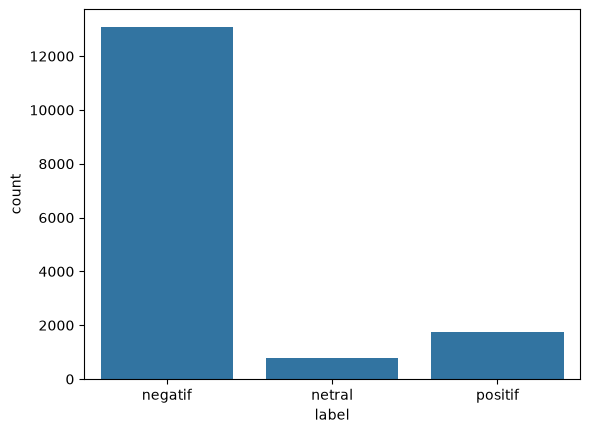

In [15]:
base = "https://raw.githubusercontent.com/fajri91/InSet/master/"
def load_lex(name):
    try:
        raw = urllib.request.urlopen(base + name).read().decode("utf-8")
        d = pd.read_csv(io.StringIO(raw), sep="\t")
    except Exception:
        d = pd.read_csv(name, sep="\t")   # fallback: taruh positive.tsv / negative.tsv di folder ini
    return dict(zip(d.iloc[:,0], d.iloc[:,1].astype(float)))
lex = {**load_lex("positive.tsv"), **load_lex("negative.tsv")}
print("Ukuran leksikon:", len(lex))

def lex_score(text):
    toks, s = text.split(), 0.0
    for i, w in enumerate(toks):
        v = lex.get(w, 0.0)
        if i > 0 and toks[i-1] in negations: v = -v
        s += v
    return s

df["skor"] = df["clean"].apply(lex_score)
df["label"] = df["skor"].apply(lambda s: "positif" if s > 0 else ("negatif" if s < 0 else "netral"))
print(df["label"].value_counts())
sns.countplot(x="label", data=df, order=["negatif","netral","positif"]); plt.show()

## 4. Encoding label

In [16]:
classes = ["negatif","netral","positif"]
y = df["label"].map({c:i for i,c in enumerate(classes)}).values
X = df["clean"].values
print("Total sampel:", len(X))

Total sampel: 15613


## Skema 1 — TF-IDF + LinearSVC (split 80/20)

In [17]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
tfidf = TfidfVectorizer(max_features=15000, ngram_range=(1,2))
Xtr_t, Xte_t = tfidf.fit_transform(Xtr), tfidf.transform(Xte)
svm = LinearSVC(C=1.0).fit(Xtr_t, ytr)
acc1_tr = accuracy_score(ytr, svm.predict(Xtr_t)); acc1_te = accuracy_score(yte, svm.predict(Xte_t))
print(f"Skema 1 | Train: {acc1_tr:.4f} | Test: {acc1_te:.4f}")
print(classification_report(yte, svm.predict(Xte_t), target_names=classes))

Skema 1 | Train: 0.9930 | Test: 0.9030
              precision    recall  f1-score   support

     negatif       0.92      0.98      0.95      2616
      netral       0.55      0.18      0.27       157
     positif       0.81      0.63      0.71       350

    accuracy                           0.90      3123
   macro avg       0.76      0.60      0.64      3123
weighted avg       0.89      0.90      0.89      3123



## Skema 2 — Tokenizer + Embedding + BiLSTM (split 80/20)

Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 13s 64ms/step - accuracy: 0.8458 - loss: 0.4726 - val_accuracy: 0.8871 - val_loss: 0.3237
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.9077 - loss: 0.2625 - val_accuracy: 0.8943 - val_loss: 0.2747
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.9345 - loss: 0.1870 - val_accuracy: 0.9095 - val_loss: 0.2884
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.9492 - loss: 0.1411 - val_accuracy: 0.9047 - val_loss: 0.3123
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.9612 - loss: 0.1157 - val_accuracy: 0.9039 - val_loss: 0.3258
Epoch 6/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.9703 - loss: 0.0902 - val_accuracy: 0.8919 - val_loss: 0.4045
Epoch 7/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.9754 - loss: 0.0735 - val_accuracy: 0.8895 - val_loss: 0.3793
Epoch 8/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.9788 - loss: 0.0642 - val_acc

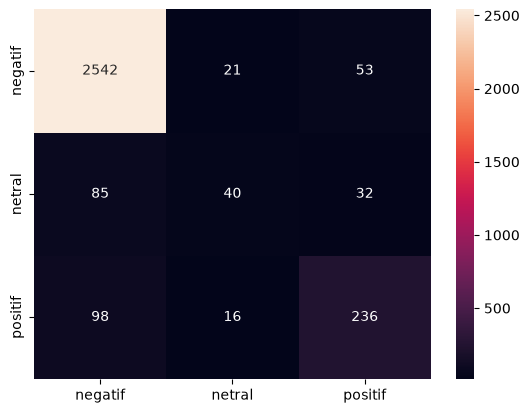

In [18]:
MAXW, MAXLEN = 15000, 60
seq = lambda tk, a: pad_sequences(tk.texts_to_sequences(a), maxlen=MAXLEN, padding="post", truncating="post")
tok2 = Tokenizer(num_words=MAXW, oov_token="<OOV>"); tok2.fit_on_texts(Xtr)
Xtr_s, Xte_s = seq(tok2, Xtr), seq(tok2, Xte)

model2 = models.Sequential([
    layers.Embedding(MAXW, 128),
    layers.Bidirectional(layers.LSTM(64, dropout=0.3)),
    layers.Dense(64, activation="relu"), layers.Dropout(0.4),
    layers.Dense(3, activation="softmax")])
model2.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
es = callbacks.EarlyStopping(monitor="val_accuracy", patience=7, restore_best_weights=True)
h2 = model2.fit(Xtr_s, ytr, validation_split=0.1, epochs=20, batch_size=64, callbacks=[es], verbose=1)
acc2_tr = model2.evaluate(Xtr_s, ytr, verbose=0)[1]; acc2_te = model2.evaluate(Xte_s, yte, verbose=0)[1]
print(f"Skema 2 | Train: {acc2_tr:.4f} | Test: {acc2_te:.4f}")
pred2 = model2.predict(Xte_s).argmax(1)
print(classification_report(yte, pred2, target_names=classes))
sns.heatmap(confusion_matrix(yte, pred2), annot=True, fmt="d", xticklabels=classes, yticklabels=classes); plt.show()

## Skema 3 — Tokenizer + Embedding + BiGRU (split 70/30)

In [19]:
Xtr3, Xte3, ytr3, yte3 = train_test_split(X, y, test_size=0.3, stratify=y, random_state=SEED)
tok3 = Tokenizer(num_words=MAXW, oov_token="<OOV>"); tok3.fit_on_texts(Xtr3)
Xtr3_s, Xte3_s = seq(tok3, Xtr3), seq(tok3, Xte3)
model3 = models.Sequential([
    layers.Embedding(MAXW, 128),
    layers.Bidirectional(layers.GRU(64, dropout=0.3)),
    layers.Dense(64, activation="relu"), layers.Dropout(0.4),
    layers.Dense(3, activation="softmax")])
model3.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
h3 = model3.fit(Xtr3_s, ytr3, validation_split=0.1, epochs=20, batch_size=64, callbacks=[es], verbose=1)
acc3_tr = model3.evaluate(Xtr3_s, ytr3, verbose=0)[1]; acc3_te = model3.evaluate(Xte3_s, yte3, verbose=0)[1]
print(f"Skema 3 | Train: {acc3_tr:.4f} | Test: {acc3_te:.4f}")

Epoch 1/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - accuracy: 0.8438 - loss: 0.4841 - val_accuracy: 0.8783 - val_loss: 0.3289
Epoch 2/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.9048 - loss: 0.2710 - val_accuracy: 0.9003 - val_loss: 0.2936
Epoch 3/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.9320 - loss: 0.1946 - val_accuracy: 0.9085 - val_loss: 0.2995
Epoch 4/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.9499 - loss: 0.1436 - val_accuracy: 0.9094 - val_loss: 0.3445
Epoch 5/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.9614 - loss: 0.1158 - val_accuracy: 0.9085 - val_loss: 0.3373
Epoch 6/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.9716 - loss: 0.0858 - val_accuracy: 0.8930 - val_loss: 0.3973
Epoch 7/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.9758 - loss: 0.0698 - val_accuracy: 0.8975 - val_loss: 0.4165
Epoch 8/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.9805 - loss: 0.0641 - val_acc

## Ringkasan skema pelatihan

In [20]:
pd.DataFrame({
 "Skema":["1","2","3"],
 "Algoritma":["LinearSVC","BiLSTM","BiGRU"],
 "Ekstraksi Fitur":["TF-IDF (1-2 gram)","Tokenizer+Embedding","Tokenizer+Embedding"],
 "Split":["80/20","80/20","70/30"],
 "Acc Train":[acc1_tr,acc2_tr,acc3_tr],"Acc Test":[acc1_te,acc2_te,acc3_te]}).round(4)

,Skema,Algoritma,Ekstraksi Fitur,Split,Acc Train,Acc Test
0,1,LinearSVC,TF-IDF (1-2 gram),80/20,0.9930,0.9030
1,2,BiLSTM,Tokenizer+Embedding,80/20,0.9502,0.9023
2,3,BiGRU,Tokenizer+Embedding,70/30,0.9613,0.8945


## Inference (output kelas kategorikal)

In [21]:
def predict_sentiment(texts):
    cleaned = [clean(t) for t in texts]
    p = model2.predict(seq(tok2, cleaned), verbose=0)
    return [(t, classes[i], float(p[k][i])) for k,(t,i) in enumerate(zip(texts, p.argmax(1)))]

contoh = ["Aplikasinya bagus banget, pengiriman cepat dan mudah dipakai",
          "Aplikasi sering error, kecewa banget, tidak bisa login",
          "Biasa saja, fiturnya standar",
          "Driver ramah dan pelayanan memuaskan",
          "Aplikasi lemot dan banyak bug, sangat mengecewakan"]
for t, label, conf in predict_sentiment(contoh):
    print(f"{label.upper():8s} ({conf:.2f}) | {t}")

NEGATIF  (1.00) | Aplikasinya bagus banget, pengiriman cepat dan mudah dipakai
NEGATIF  (1.00) | Aplikasi sering error, kecewa banget, tidak bisa login
NEGATIF  (0.99) | Biasa saja, fiturnya standar
NEGATIF  (0.68) | Driver ramah dan pelayanan memuaskan
NEGATIF  (1.00) | Aplikasi lemot dan banyak bug, sangat mengecewakan


In [22]:
model2.save("model_sentimen_bilstm.keras")
df[["content","clean","label"]].to_csv("dataset_berlabel.csv", index=False)